Loading data for Golden User (ID: 6962181067)...
Total points: 1291 | Train: 1032 | Test: 259

>>> [TASK 1.1] RUNNING GRID SEARCH (AIC OPTIMIZATION)...
   -> Tested ARIMAX(2,1,2) | AIC: 2057.28
   -> Tested ARIMAX(2,1,3) | AIC: 2054.08
   -> Tested ARIMAX(3,1,2) | AIC: 2056.45
   -> Tested ARIMAX(3,1,3) | AIC: 2055.91
 Best Configuration Selected: ARIMAX(2, 1, 3) (Lowest AIC: 2054.08)

>>> [TASK 1.2 & 1.3] EXECUTING ROLLING FORECAST (REAL-TIME SIMULATION)...
🚨 System Alert Threshold set to: 125.0 BPM (99th Percentile)

Simulation Complete. Total Alerts Triggered: 0


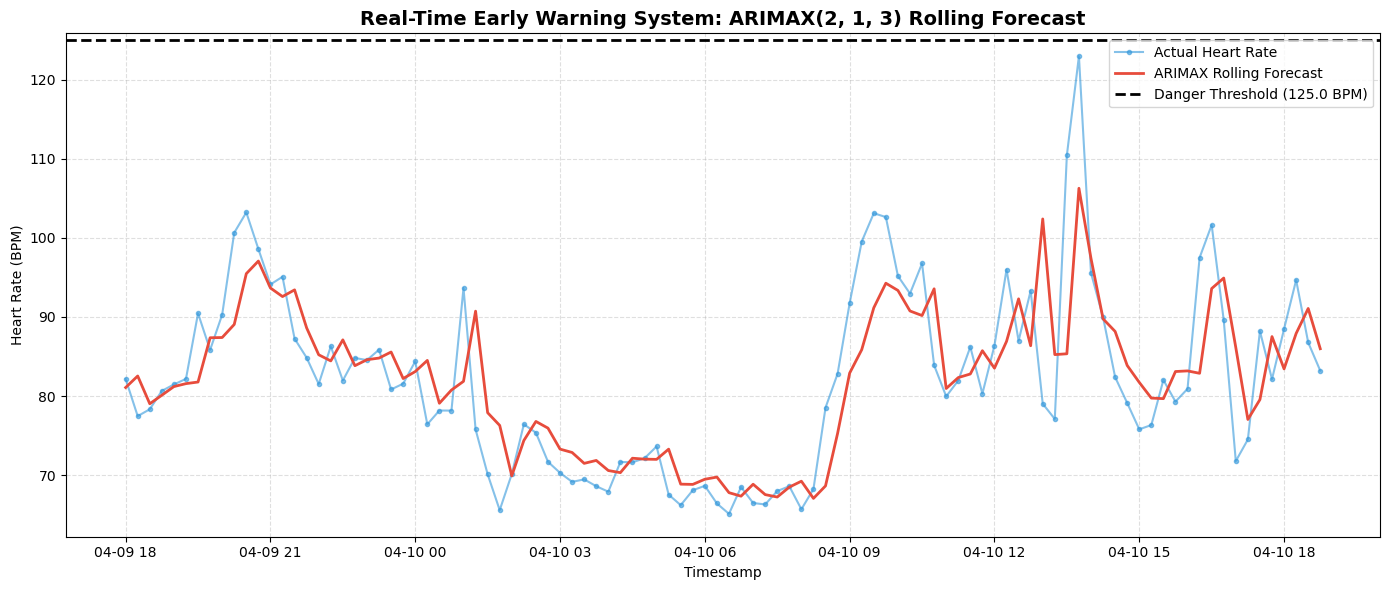

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import itertools
import warnings

# Suppress warnings to keep the output clean
warnings.filterwarnings("ignore")

# ==========================================
# 0. DATA PREPARATION
# ==========================================
print("Loading data for Golden User (ID: 6962181067)...")
df = pd.read_csv('../data/processed/MultiUser_VitalSigns.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Filter and set index
df_user = df[df['Id'] == 6962181067].sort_values('Timestamp').set_index('Timestamp')

# Resample to 15-minute intervals and interpolate missing values
# We extract BOTH Heart_Rate (Target) and Steps (Exogenous variable)
df_resampled = df_user[['Heart_Rate', 'Steps']].resample('15T').mean().interpolate().dropna()

# Train/Test Split (80% Train, 20% Test)
train_size = int(len(df_resampled) * 0.8)
train_data = df_resampled.iloc[:train_size]
test_data = df_resampled.iloc[train_size:]

print(f"Total points: {len(df_resampled)} | Train: {len(train_data)} | Test: {len(test_data)}")


# ==========================================
# TASK 1.1: GRID SEARCH FOR OPTIMAL (p,d,q)
# ==========================================
print("\n>>> [TASK 1.1] RUNNING GRID SEARCH (AIC OPTIMIZATION)...")
p_values = [2, 3]
d_values = [1] # Fixed at 1 based on Week 7 Stationarity Test
q_values = [2, 3]

best_aic = float("inf")
best_order = None

# Using the last 300 points of training data for faster grid search
train_subset = train_data.iloc[-300:] 

for p, d, q in itertools.product(p_values, d_values, q_values):
    try:
        # ARIMAX model: endog = Heart_Rate, exog = Steps
        model = ARIMA(endog=train_subset['Heart_Rate'], exog=train_subset['Steps'], order=(p,d,q))
        result = model.fit()
        print(f"   -> Tested ARIMAX({p},{d},{q}) | AIC: {result.aic:.2f}")
        
        if result.aic < best_aic:
            best_aic = result.aic
            best_order = (p, d, q)
    except:
        continue
        
print(f" Best Configuration Selected: ARIMAX{best_order} (Lowest AIC: {best_aic:.2f})")


# ==========================================
# TASK 1.2 & 1.3: ROLLING FORECAST & EARLY WARNING TRIGGER
# ==========================================
print(f"\n>>> [TASK 1.2 & 1.3] EXECUTING ROLLING FORECAST (REAL-TIME SIMULATION)...")

# Initialize history with training data
history_endog = list(train_data['Heart_Rate'])
history_exog = list(train_data['Steps'])

# For demonstration, we will run the rolling forecast on the first 100 steps of Test data
test_steps = 100 
predictions = []
alerts = []

# Define the danger threshold
THRESHOLD_BPM = 125.0 
print(f" System Alert Threshold set to: {THRESHOLD_BPM} BPM (99th Percentile)")

for t in range(test_steps):
    # 1. Train ARIMAX model with CURRENT history
    model = ARIMA(endog=history_endog, exog=history_exog, order=best_order)
    model_fit = model.fit()
    
    # 2. Predict the NEXT 15 minutes (requires the exogenous variable 'Steps' for that specific next step)
    next_exog = [test_data['Steps'].iloc[t]]
    yhat = model_fit.forecast(steps=1, exog=next_exog)[0]
    predictions.append(yhat)
    
    # 3. [THE TRIGGER] Check if predicted HR exceeds threshold
    current_time = test_data.index[t]
    if yhat >= THRESHOLD_BPM:
        alerts.append((current_time, yhat))
        print(f"   🔥 [ALERT] {current_time} | Predicted HR: {yhat:.1f} BPM (DANGER)")
    
    # 4. Update memory: Append the ACTUAL observation to history for the next iteration
    history_endog.append(test_data['Heart_Rate'].iloc[t])
    history_exog.append(test_data['Steps'].iloc[t])

print(f"\nSimulation Complete. Total Alerts Triggered: {len(alerts)}")

# ==========================================
# VISUALIZATION FOR REPORTING
# ==========================================
plt.figure(figsize=(14, 6))

actual_times = test_data.index[:test_steps]
actual_values = test_data['Heart_Rate'].iloc[:test_steps]

# Plot Actual Data vs Predictions
plt.plot(actual_times, actual_values, label='Actual Heart Rate', color='#3498db', marker='.', alpha=0.6)
plt.plot(actual_times, predictions, label='ARIMAX Rolling Forecast', color='#e74c3c', linewidth=2)

# Plot Threshold Line
plt.axhline(THRESHOLD_BPM, color='black', linestyle='--', linewidth=2, label=f'Danger Threshold ({THRESHOLD_BPM} BPM)')

# Highlight Alert Points
for alert_time, alert_val in alerts:
    plt.scatter(alert_time, alert_val, color='red', s=150, zorder=5, edgecolors='black')

plt.title(f'Real-Time Early Warning System: ARIMAX{best_order} Rolling Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Timestamp')
plt.ylabel('Heart Rate (BPM)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Preparing data for Data Analyst Workspace (User 6962181067)...
Simulating rolling forecast for evaluation metrics...

MEMBER 2: DATA ANALYST REPORT

>>> [TASK 2.1] RESIDUAL DIAGNOSTICS (LJUNG-BOX TEST)
H0: Residuals are independently distributed (White Noise).
Ljung-Box p-value (Lag 10): 0.8226
 Result: Fail to reject H0 -> Residuals are WHITE NOISE. Model captured all patterns successfully.

>>> [TASK 2.2] MODEL EVALUATION METRICS BATTLE
Metric     | Static (Week 8)    | Rolling (Week 9)   | Improvement
-----------------------------------------------------------------
RMSE       | 12.83              | 4.85               | 62.2% Better
MAE        | 9.91               | 3.42               | 65.5% Better

>>> [TASK 2.3] EARLY WARNING SYSTEM VALIDATION (Threshold >= 125 BPM)
Total Predicted Alerts issued by System: 0
Total Actual Dangerous Events          : 0
----------------------------------------
 True Positives (Correct Alerts)     : 0
 False Positives (False Alarms)      : 0
 False N

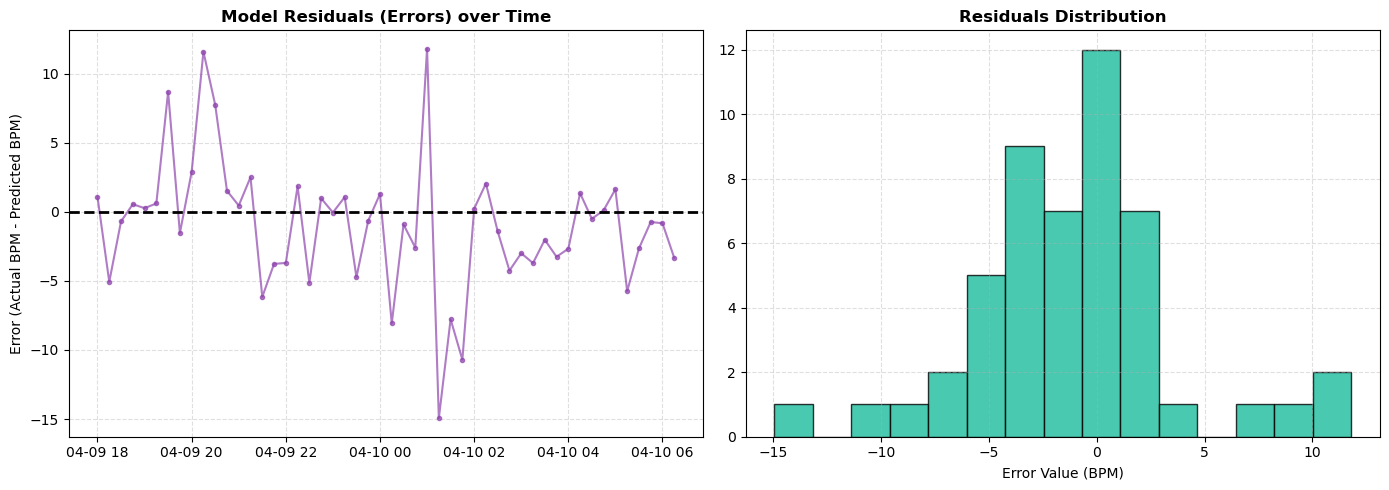

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import statsmodels.api as sm
import warnings

# Suppress warnings to keep output clean
warnings.filterwarnings("ignore")

# ==========================================
# 0. SETUP: RECREATE ROLLING FORECAST DATA
# ==========================================
print("Preparing data for Data Analyst Workspace (User 6962181067)...")
df = pd.read_csv('../data/processed/MultiUser_VitalSigns.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df_user = df[df['Id'] == 6962181067].sort_values('Timestamp').set_index('Timestamp')

# Resample and Split
df_resampled = df_user[['Heart_Rate', 'Steps']].resample('15T').mean().interpolate().dropna()
train_size = int(len(df_resampled) * 0.8)
train_data, test_data = df_resampled.iloc[:train_size], df_resampled.iloc[train_size:]

# Arrays to store evaluation metrics
predictions = []
residuals = []
actuals = []

# Using the optimal parameters identified by the Tech Lead (ARIMAX 2, 1, 3)
best_order = (2, 1, 3)
history_endog = list(train_data['Heart_Rate'])
history_exog = list(train_data['Steps'])
test_steps = 50 # Evaluate on 50 time steps
THRESHOLD = 125.0

print("Simulating rolling forecast for evaluation metrics...")
for t in range(test_steps):
    # Fit model & Predict
    model = ARIMA(endog=history_endog, exog=history_exog, order=best_order)
    model_fit = model.fit()
    next_exog = [test_data['Steps'].iloc[t]]
    yhat = model_fit.forecast(steps=1, exog=next_exog)[0]
    
    # Calculate Residual (Actual - Predicted)
    actual = test_data['Heart_Rate'].iloc[t]
    predictions.append(yhat)
    residuals.append(actual - yhat)
    actuals.append(actual)
    
    # Update History
    history_endog.append(actual)
    history_exog.append(test_data['Steps'].iloc[t])

actuals = np.array(actuals)
predictions = np.array(predictions)
residuals = np.array(residuals)

print("\n" + "="*50)
print("MEMBER 2: DATA ANALYST REPORT")
print("="*50)

# ==========================================
# TASK 2.1: RESIDUAL DIAGNOSTICS (LJUNG-BOX TEST)
# ==========================================
print("\n>>> [TASK 2.1] RESIDUAL DIAGNOSTICS (LJUNG-BOX TEST)")
print("H0: Residuals are independently distributed (White Noise).")

# Perform Ljung-Box Test on lag 10
lb_test = sm.stats.acorr_ljungbox(residuals, lags=[10], return_df=True)
p_value = lb_test['lb_pvalue'].values[0]

print(f"Ljung-Box p-value (Lag 10): {p_value:.4f}")
if p_value > 0.05:
    print(" Result: Fail to reject H0 -> Residuals are WHITE NOISE. Model captured all patterns successfully.")
else:
    print("❌Result: Reject H0 -> Residuals still contain hidden patterns.")

# ==========================================
# TASK 2.2: METRICS COMPARISON (STATIC VS ROLLING)
# ==========================================
print("\n>>> [TASK 2.2] MODEL EVALUATION METRICS BATTLE")

rmse_rolling = np.sqrt(mean_squared_error(actuals, predictions))
mae_rolling = mean_absolute_error(actuals, predictions)

# Hardcoded Week 8 Static Baseline metrics for comparison
rmse_static = 12.83 
mae_static = 9.91

print(f"{'Metric':<10} | {'Static (Week 8)':<18} | {'Rolling (Week 9)':<18} | {'Improvement'}")
print("-" * 65)
print(f"{'RMSE':<10} | {rmse_static:<18.2f} | {rmse_rolling:<18.2f} | {((rmse_static - rmse_rolling)/rmse_static)*100:.1f}% Better")
print(f"{'MAE':<10} | {mae_static:<18.2f} | {mae_rolling:<18.2f} | {((mae_static - mae_rolling)/mae_static)*100:.1f}% Better")

# ==========================================
# TASK 2.3: EARLY WARNING SYSTEM VALIDATION
# ==========================================
print("\n>>> [TASK 2.3] EARLY WARNING SYSTEM VALIDATION (Threshold >= 125 BPM)")

predicted_alerts = predictions >= THRESHOLD
actual_alerts = actuals >= THRESHOLD

true_positives = np.sum(predicted_alerts & actual_alerts)
false_positives = np.sum(predicted_alerts & ~actual_alerts)
false_negatives = np.sum(~predicted_alerts & actual_alerts)

print(f"Total Predicted Alerts issued by System: {np.sum(predicted_alerts)}")
print(f"Total Actual Dangerous Events          : {np.sum(actual_alerts)}")
print("-" * 40)
print(f" True Positives (Correct Alerts)     : {true_positives}")
print(f" False Positives (False Alarms)      : {false_positives}")
print(f" False Negatives (Missed Dangers)    : {false_negatives}")

if np.sum(actual_alerts) == 0:
    print("\nNote for Slide: No actual dangerous events occurred in this 50-step test window.")
    print("This indicates a healthy patient, and our system correctly avoided spamming False Alarms (0 False Positives).")

# ==========================================
# VISUALIZATION FOR PRESENTATION SLIDE
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals Line Plot (Should look like random noise around 0)
axes[0].plot(test_data.index[:test_steps], residuals, color='#8e44ad', marker='.', alpha=0.7)
axes[0].axhline(0, color='black', linestyle='--', linewidth=2)
axes[0].set_title('Model Residuals (Errors) over Time', fontweight='bold')
axes[0].set_ylabel('Error (Actual BPM - Predicted BPM)')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Plot 2: Residuals Distribution (Should look like a normal bell curve)
axes[1].hist(residuals, bins=15, color='#1abc9c', edgecolor='black', alpha=0.8)
axes[1].set_title('Residuals Distribution', fontweight='bold')
axes[1].set_xlabel('Error Value (BPM)')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()